# 위밋모빌리티 — 해상 리스크 대응형 공동 물류 운영 플랫폼 (v4)

> **주관**: 한국해양수산개발원(KMI) × 위밋모빌리티  
> **대회**: 2026학년도 1학기 기업문제해결 프로젝트 공모전  
> **기간**: 2026.04.29 ~ 2026.05.20 (3주)

---

## 📌 한 줄 정의

> 해상 리스크로 출항 지연·운임 변동·선복 차질이 발생했을 때,  
> 중소 수출기업의 출하 예정 건을 **집화 일정·항만 반입 시점·권역별 통합 집화·운송 우선순위** 기준으로 재조정하고,  
> 그 결과를 **위밋 루티/루티프로가 활용할 수 있는 입력 정보**로 제공하는 공동 물류 운영 플랫폼

---

## 🗂️ 노트북 구성

| Part | 내용 | 핵심 기법 |
|---|---|---|
| **Part 0** | 환경 설정 & 데이터 현황 | .env, API 상태 |
| **Part 1** | 뉴스 수집 & NLP 분류 | RSS, 키워드 사전 |
| **Part 2** | MRI 산출 (AHP 기반) | IAHP, 4대 리스크 차원 |
| **Part 3** | 부산항 물동량 & LSTM 예측 | 시계열 분할, LSTM |
| **Part 4** | MRI 유사사례 매칭 | 과거 사례 DB, 고객 정보 제공 |
| **Part 5** | 창고·ODCY 자동 추천 | 카카오 API, 3모드 추천 |
| **Part 6** | 루티 JSON (창고 운송) | Phase 1·2 JSON, 시나리오 |


---
# Part 0 — 환경 설정 & 데이터 현황

노트북 실행에 필요한 패키지를 불러오고, API 키 상태를 확인합니다.

In [1]:
# ──────────────────────────────────────────────────────────
# 0-1. 기본 패키지 임포트
# ──────────────────────────────────────────────────────────
import os, sys, warnings, json, random, logging
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')

# 프로젝트 루트 경로 설정
# CWD가 프로젝트 루트인지 notebooks/ 인지 자동 판별
ROOT = Path().resolve()
if not (ROOT / 'src').exists():   # notebooks/ 에서 실행된 경우
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# .env 로드 (API 키)
try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / '.env', override=False)
    print('✅ .env 로드 완료')
except ImportError:
    print('⚠️ python-dotenv 미설치 → pip install python-dotenv')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 (그래프 □ 깨짐 방지) ────────────────────
# 핵심 원인: matplotlib 기본 폰트는 한글 미지원 → 한글이 □로 표시됨
# 해결: 시스템 폰트 목록에서 한글 지원 폰트를 탐색 후 강제 지정
# fm._rebuild(): 폰트 캐시를 초기화해 새로 설치된 폰트도 인식하게 함
try:
    fm._rebuild()          # 폰트 캐시 강제 갱신 (Jupyter 재시작 없이 적용)
except Exception:
    pass

_KR_FONTS = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'NanumBarunGothic']
_available = {f.name for f in fm.fontManager.ttflist}
_font_set  = False
for _f in _KR_FONTS:
    if _f in _available:
        plt.rcParams['font.family'] = _f
        _font_set = True
        print(f'✅ 한글 폰트 설정: {_f}')
        break
if not _font_set:
    print('⚠️ 한글 폰트 미발견 — 그래프 한글이 □로 표시될 수 있음')
    print('   해결: pip install matplotlib 후 Malgun Gothic 확인')
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(-) 기호 깨짐 방지

# PyTorch / Plotly 설치 여부 확인
try:
    import torch
    TORCH_OK = True
except ImportError:
    TORCH_OK = False

# 시드 고정 (재현성 — 난수 기반 시뮬이 매번 동일하게 실행됨)
np.random.seed(42)
random.seed(42)

# 폴더 생성
DATA_DIR  = ROOT / 'data'
CACHE_DIR = ROOT / 'data' / 'ecos_cache'
ROUTY_DIR = ROOT / 'routy_inputs'
for d in [DATA_DIR, CACHE_DIR, ROUTY_DIR]:
    d.mkdir(exist_ok=True)

print('\n📦 실행 환경')
print(f'  Python 루트: {ROOT}')
print(f'  PyTorch:     {"✅ 사용 가능" if TORCH_OK else "❌ 미설치 (LSTM 건너뜀)"}')

✅ .env 로드 완료
✅ 한글 폰트 설정: Malgun Gothic

📦 실행 환경
  Python 루트: C:\Users\USER\Desktop\vs code\vs code
  PyTorch:     ✅ 사용 가능


In [2]:
# 0-2. 데이터 소스 전체 현황
from src.real_data_fetcher import print_data_status
print_data_status()

print('\n[운임지수 (KCCI)]')
kcci_csv = DATA_DIR / 'kcci_weekly.csv'
xls_files = list((DATA_DIR/'freight_index').glob('*.xls')) + list((DATA_DIR/'freight_index').glob('*.xlsx'))
if kcci_csv.exists():
    import pandas as _pd
    _k = _pd.read_csv(kcci_csv, encoding='utf-8-sig')
    print(f'  kcci_weekly.csv: {len(_k)}주 (XLS 합치기 완료)')
elif xls_files:
    print(f'  XLS {len(xls_files)}개 확인 → --combine-freight 실행 필요')
else:
    print('  없음 → data/freight_index/ 에 XLS 저장 후 --combine-freight 실행')

print('\n[부산항 컨테이너 물동량]')
print('  2020~2024: BPA 공공데이터포털 API (데이터셋 15055478)')
print('             → 연도별 TEU + 계절 분해 → 월별 추정치')
print('  2025:      수동 수집 Excel (BPA 홈페이지 업데이트 자료)')
print('             → 260414_홈페이지 업데이트_전국항 및 부산항 컨테이너 물동량')
print('             → 2025년 연간 합계 24,882,355 TEU → 월평균 207.4만 TEU')
from src.data_loader import load_busan_throughput_combined
_tp = load_busan_throughput_combined(DATA_DIR, start_year=2020)
if _tp is not None:
    print(f'  로드 완료: {len(_tp)}개월 ({_tp["date"].iloc[0].strftime("%Y.%m")} ~ {_tp["date"].iloc[-1].strftime("%Y.%m")})')
else:
    print('  로드 실패 → 시뮬 폴백')

import json as _json
rates_fp = DATA_DIR / 'today_rates.json'
if rates_fp.exists():
    _rates = _json.loads(rates_fp.read_text(encoding='utf-8'))
    _today_key = sorted(_rates.keys())[-1]
    _d = _rates[_today_key]
    print(f'\n[오늘 자동수집 실데이터] ({_today_key})')
    if 'usd_krw' in _d: print(f'  환율: {_d["usd_krw"]:,.0f}원/달러  [frankfurter.app]')
    if 'brent_usd' in _d: print(f'  유가: ${_d["brent_usd"]:.2f}/배럴 (Brent)  [Yahoo Finance]')

print('\n[자동 갱신 스케줄]')
print('  매일  08:30   환율 (frankfurter.app) + 유가 (Yahoo Finance BZ=F)')
print('  매주 월 09:00  운임지수 (XLS 폴더 감시 + 합치기)')
print('  등록: .\\scripts\\setup_scheduler.ps1')


  데이터 소스 현황

[API 키]
  ECOS (한국은행):       ✅ 설정됨  → 환율·두바이유 공식
     ※ 통계코드 시도순: 731Y003/0000001 → 731Y001/0000001 → 021Y151/USD
     ※ 유가 시도순:    902Y020/I61B → 902Y020/I61BCS
     ※ ECOS 실패 시 → frankfurter.app(환율) / FRED(유가) 자동 대체
  BPA (부산항만공사):    ✅ 설정됨  → 컨테이너 물동량 (연도별)
     ※ BPA API 실패 시 → data/busan_throughput.csv 수동 다운로드 필요
  KCCI (공공데이터포털): ❌ 미설정  → 운임지수
     ※ 발급: https://www.data.go.kr/data/15131881/openapi.do

[CSV 파일 (직접 다운로드)]
  KCCI:   ❌ 없음
         다운로드: https://www.forwarder.kr/freight/index/kcci
  부산항: ❌ 없음
         다운로드: https://www.busanpa.com/kor/Contents.do?mCode=MN1003

[자동 수집 (키 불필요, 매일 08:30 자동 갱신)]
  해사 뉴스 RSS: gCaptain / Splash247 / 한국해운신문
  USD/KRW 환율:  frankfurter.app (일별 실시간)
  Brent 유가:   Yahoo Finance BZ=F (일별 실시간)
              → FRED MCOILBRENTEU (Yahoo 실패 시 폴백)
              → EIA DEMO키 (최후 폴백)
  갱신 명령:    python scripts/auto_update.py --mode daily


[운임지수 (KCCI)]
  kcci_weekly.csv: 174주 (XLS 합치기 완료)

[부산항 컨테이너 물동량]
  2020~2024: BPA 공공데이터포털 API (데이터셋 1

In [3]:
# 0-4. 운임지수 XLS (KCCI / KUWI / KUEI)
# 파일 위치: data/freight_index/*.xls
# 합치기: python scripts/auto_update.py --combine-freight
from src.freight_index_loader import load_all_indices, load_kcci_weekly
FREIGHT_DIR = DATA_DIR / 'freight_index'
FREIGHT_DIR.mkdir(exist_ok=True)
print('운임지수 확인...')
freight_all = load_all_indices(DATA_DIR)
freight_df  = load_kcci_weekly(DATA_DIR)
if freight_all is not None:
    idx_cols = [c for c in freight_all.columns if c != 'date']
    print(f'XLS 실데이터: {len(freight_all)}주')
    print(f'기간: {freight_all["date"].min().strftime("%Y.%m.%d")} ~ {freight_all["date"].max().strftime("%Y.%m.%d")}')
    print(f'지수: {idx_cols}')
    if 'kcci' in freight_all.columns:
        latest = freight_all.dropna(subset=['kcci']).iloc[-1]
        print(f'최신 KCCI: {latest["kcci"]:.0f} ({latest["date"].strftime("%Y.%m.%d")})')
else:
    freight_df = None
    print('XLS 없음 -> 시뮬 사용')
    print('data/freight_index/ 에 XLS 저장 후 --combine-freight 실행')


운임지수 확인...
XLS 실데이터: 174주
기간: 2022.11.07 ~ 2026.04.27
지수: ['kcci', 'kuwi', 'kuei']
최신 KCCI: 2192 (2026.04.27)


---
# Part 1 — 뉴스 수집 & NLP 리스크 분류

## 1-1. 왜 뉴스 데이터를 사용하는가?

해운 리스크는 **사건 발생 후 수 시간 내**에 뉴스로 먼저 확인됩니다.  
공식 통계(항만물동량, 운임지수)는 주간/월간 단위로 발표되므로, 실시간성이 부족합니다.

| 비교 항목 | 뉴스 (RSS) | 공식 통계 (KCCI 등) |
|---|---|---|
| 업데이트 주기 | 실시간 | 주 1회 |
| 선행성 | ✅ 조기 경보 | ❌ 사후 확인 |
| 비용 | 무료 | 일부 유료 |

## 1-2. 분류 카테고리 (6종)

| 카테고리 | 의미 | 리스크 가중치 |
|---|---|---|
| 지정학분쟁 | 전쟁·봉쇄·테러 | **1.0** (최고) |
| 항만파업 | 노조·파업·하역 거부 | 0.85 |
| 기상재해 | 태풍·폭풍·결항 | 0.75 |
| 관세정책 | 관세부과·무역전쟁·CBAM | 0.65 |
| 운임급등 | KCCI·SCFI·선복 부족 | 0.55 |
| 정상 | 정상화·회복·안정 | 0.00 |

In [4]:
# ══════════════════════════════════════════════════════
# Step 1. 화주 데이터 입력
# 아래 값을 수정하면 이후 전체 분석이 자동으로 반영됩니다.
# 실제 서비스: 웹폼/앱 입력값이 이 변수들에 자동 주입됩니다.
# ══════════════════════════════════════════════════════
from src.odcy_recommender import CargoType
import os

# ── 화주 입력 정보 ──────────────────────────────────────
SHIPPER_INPUT = {
    "company":        "테스트화주(주)",
    "cargo_type_str": "일반화물",        # 일반화물 / 냉장화물 / 위험물
    "cbm":            15.0,              # 화물 용량 (CBM)
    "origin_address": "경기도 수원시 영통구",
    "route":          "부산\u2192로테르담",
    "pickup_date":    "2026-05-20",
    "deadline_days":  14,
    "urgent":         False,
}

# 항로 → 출발 항만 자동 결정
ROUTE_TO_PORT = {
    "부산\u2192로테르담": "부산항(북항)",
    "부산\u2192LA":       "부산항(북항)",
    "부산\u2192상하이":   "부산항(북항)",
    "부산\u2192싱가포르": "부산 신항",
    "부산\u2192도쿄":     "부산항(북항)",
}
DEPARTURE_PORT = ROUTE_TO_PORT.get(SHIPPER_INPUT["route"], "부산항(북항)")

# 화물유형 문자열 → CargoType enum 자동 변환
CARGO_TYPE_MAP = {
    "일반화물":  CargoType.GENERAL,
    "냉장화물":  CargoType.REFRIGERATED,
    "위험물":    CargoType.HAZMAT,
    "자동차부품": CargoType.AUTO_PARTS,
    "2차전지":   CargoType.BATTERY,
    "의류/섬유": CargoType.APPAREL,
    "전자제품":  CargoType.ELECTRONICS,
}
CARGO_ENUM = CARGO_TYPE_MAP.get(SHIPPER_INPUT["cargo_type_str"], CargoType.GENERAL)

# 출발지 주소 → 권역 자동 결정 (실제 서비스: 카카오 지오코딩 사용)
def _addr_to_region(addr: str) -> str:
    if any(k in addr for k in ["수원", "화성", "평택", "안산", "용인", "안양"]):
        return "경기남부"
    if any(k in addr for k in ["서울", "경기", "인천", "의정부", "고양", "파주"]):
        return "경기북부"
    if any(k in addr for k in ["충남", "충북", "대전", "세종", "천안", "아산"]):
        return "충청"
    if any(k in addr for k in ["부산", "울산", "경남", "창원", "진주"]):
        return "경상남부"
    if any(k in addr for k in ["대구", "경북", "포항", "구미", "안동"]):
        return "경상북도"
    return "경기남부"

SHIPPER_REGION = _addr_to_region(SHIPPER_INPUT["origin_address"])

print("=" * 55)
print("Step 1. 화주 입력 정보")
print("=" * 55)
print(f"  회사명    : {SHIPPER_INPUT['company']}")
print(f"  화물 유형 : {SHIPPER_INPUT['cargo_type_str']} → {CARGO_ENUM.value}")
print(f"  화물 용량 : {SHIPPER_INPUT['cbm']} CBM")
print(f"  출발지    : {SHIPPER_INPUT['origin_address']}")
print(f"  권역(자동): {SHIPPER_REGION}")
print(f"  희망 항로 : {SHIPPER_INPUT['route']}")
print(f"  출발 항만 : {DEPARTURE_PORT}")
print(f"  집화 예정 : {SHIPPER_INPUT['pickup_date']}")
print(f"  납기 여유 : {SHIPPER_INPUT['deadline_days']}일")
print("=" * 55)


Step 1. 화주 입력 정보
  회사명    : 테스트화주(주)
  화물 유형 : 일반화물 → 일반화물
  화물 용량 : 15.0 CBM
  출발지    : 경기도 수원시 영통구
  권역(자동): 경기남부
  희망 항로 : 부산→로테르담
  출발 항만 : 부산항(북항)
  집화 예정 : 2026-05-20
  납기 여유 : 14일


In [5]:
# ──────────────────────────────────────────────────────────
# 1-1. 뉴스 수집
# 우선순위: 실시간 RSS → 시뮬 데이터 보강
# RSS 소스: gCaptain, Splash247, 한국해운신문 (모두 무료)
# ──────────────────────────────────────────────────────────
from src.real_data_fetcher import fetch_maritime_news

# 실시간 뉴스 수집 시도
try:
    import feedparser
    news_df = fetch_maritime_news(max_per_source=30, days_back=30)
    real_news = not news_df.empty
    print(f'✅ 실시간 뉴스 수집: {len(news_df)}건')
except ImportError:
    news_df   = pd.DataFrame()
    real_news = False
    print('⚠️ feedparser 미설치 → pip install feedparser')

# 시뮬 뉴스 (실제 해운 뉴스 패턴 기반)
SIM_NEWS = [
    {'title': '홍해 후티 반군 공격 재개, 컨테이너 운임 급등',  'text': '홍해 항로 봉쇄로 운임 30% 상승 우려',   'source': '시뮬'},
    {'title': '부산항 컨테이너 처리량 사상 최대 갱신',         'text': '4월 처리량 전년 대비 4.8% 증가',         'source': '시뮬'},
    {'title': '태풍 카눈 북상, 부산항 입출항 차질 우려',        'text': '기상청 태풍 경보, 컨테이너선 피항 준비', 'source': '시뮬'},
    {'title': '미중 추가 관세 부과, 환적 물동량 감소',          'text': '관세 정책 변동으로 수출 기업 타격',      'source': '시뮬'},
    {'title': '호르무즈 해협 긴장 고조, 이란 미사일 위협',      'text': '지정학적 분쟁 위험 확대',               'source': '시뮬'},
    {'title': '부산항 노조 부분 파업, 하역 지연',               'text': '항만 파업으로 컨테이너 체류 시간 증가',  'source': '시뮬'},
    {'title': '글로벌 선사 운임 인상 발표',                     'text': 'Maersk, MSC 운임 5월부터 상승',         'source': '시뮬'},
    {'title': '한국 조선업 LNG선 수주 회복',                    'text': '글로벌 LNG선 발주 증가',               'source': '시뮬'},
    {'title': 'EU CBAM 본격 시행 임박, 수출기업 비상',          'text': 'CBAM 인증서 구매 부담 가중',            'source': '시뮬'},
    {'title': '부산항 신항 물동량 회복세',                      'text': '신항 정상화로 처리능력 향상',            'source': '시뮬'},
]

# 실 뉴스가 부족하면 시뮬로 보강
if len(news_df) < 5:
    news_df = pd.concat([news_df, pd.DataFrame(SIM_NEWS)], ignore_index=True)
    print(f'  시뮬 데이터로 보강 → 총 {len(news_df)}건')

print(f'\n소스별 분포: {dict(news_df["source"].value_counts()) if "source" in news_df.columns else "N/A"}')
news_df.head(5)

✅ 실시간 뉴스 수집: 52건

소스별 분포: {'한국해운신문': np.int64(30), 'gCaptain': np.int64(12), 'Splash247': np.int64(10)}


,title,text,pub_date,source
0,EU Russian Arctic LNG Imports Hit $4.4bn Recor...,European Union imports of Russian Arctic lique...,2026-05-08,gCaptain
1,"US, Iran Clash Near Hormuz as Response on Prop...",The US and Iran clashed near the Strait of Hor...,2026-05-08,gCaptain
2,U.S. Confirms Iranian Attack on U.S. Navy Dest...,"Three U.S. Navy destroyers came under missile,...",2026-05-07,gCaptain
3,House Labor Caucus Joins Growing Backlash Agai...,Opposition to the Trump administration’s sweep...,2026-05-07,gCaptain
4,Trump Administration Launches Nuclear-Powered ...,The Trump administration is opening the door t...,2026-05-07,gCaptain


In [6]:
# 1-2. NLP 키워드 분류
# [방식] 키워드 사전 기반 (Rule-Based)
#   각 카테고리별 키워드가 뉴스에 몇 개 포함되는지 카운트
#   최다 키워드 카테고리로 분류 / 동점시 리스크 가중치 우선
# [향후] KoBERT fine-tuning (본단계: 키워드 / 향후: KoBERT 80%+)
from src.nlp_classifier import classify_news_df, top_category
news_df       = classify_news_df(news_df)
today_top_cat = top_category(news_df)
cat_counts = news_df['pred_category'].value_counts()
total      = len(news_df)
RISK_LABELS = {
    '지정학분쟁': '[HIGH 1.00]', '항만파업': '[HIGH 0.85]',
    '기상재해':   '[MID  0.75]', '관세정책': '[MID  0.65]',
    '운임급등':   '[MID  0.55]', '정상':     '[LOW  0.00]',
}
print('=' * 58)
print('NLP 리스크 분류 결과')
print('=' * 58)
for cat, cnt in cat_counts.items():
    label = RISK_LABELS.get(cat, '          ')
    bar   = '#' * min(cnt, 20)
    pct   = cnt / total * 100
    print(f'  {label} {cat:<8s}: {cnt:3d}건 ({pct:4.1f}%) {bar}')
print(f'\n  최다 카테고리: {today_top_cat}  |  총 뉴스: {total}건')
high = news_df[news_df['risk_weight'] >= 0.65].head(5)
if not high.empty:
    print('\n  [고위험 뉴스 상위 5건]')
    for _, row in high.iterrows():
        print(f"    {row.get('pred_category',''):<8s} (w={row.get('risk_weight',0):.2f}) {str(row['title'])[:45]}")


NLP 리스크 분류 결과
  [LOW  0.00] 정상      :  26건 (50.0%) ####################
  [HIGH 1.00] 지정학분쟁   :  14건 (26.9%) ##############
  [MID  0.65] 관세정책    :   6건 (11.5%) ######
  [MID  0.55] 운임급등    :   3건 ( 5.8%) ###
  [HIGH 0.85] 항만파업    :   2건 ( 3.8%) ##
  [MID  0.75] 기상재해    :   1건 ( 1.9%) #

  최다 카테고리: 정상  |  총 뉴스: 52건

  [고위험 뉴스 상위 5건]
    지정학분쟁    (w=1.00) US, Iran Clash Near Hormuz as Response on Pro
    지정학분쟁    (w=1.00) U.S. Confirms Iranian Attack on U.S. Navy Des
    항만파업     (w=0.85) House Labor Caucus Joins Growing Backlash Aga
    지정학분쟁    (w=1.00) Oil Shock Far From Over: Energy Giants Warn G
    지정학분쟁    (w=1.00) Australia Bans Liberian-Flagged Bulker From P


---
# Part 2 — MRI 산출 (AHP 기반)

## 2-1. 기존 방식의 문제점

기존 MRI 공식: `0.40×부정뉴스비중 + 0.30×이벤트건수 + 0.20×운임변동 + 0.10×고위험비중`

| 문제 | 설명 |
|---|---|
| ❌ 가중치 근거 없음 | 임의로 설정 (0.4, 0.3, 0.2, 0.1) |
| ❌ 변수 중복 | 부정뉴스와 고위험비중이 실질적으로 동일한 정보 |
| ❌ 리스크 유형 미분리 | 지정학(+14일)과 기상(+5일)을 같은 비중으로 처리 |

## 2-2. AHP (계층분석법)란?

**AHP(Analytic Hierarchy Process)**는 미국 수학자 Thomas Saaty(1980)가 개발한 다기준 의사결정 방법입니다.  
복잡한 판단을 **쌍대비교(pairwise comparison)**로 분해하여 수학적으로 가중치를 도출합니다.

본 연구는 **Chen et al. (2022)** "Risk Evaluation of Navigation Environment Based on Dynamic Weight Model"  
(Journal of Marine Science and Engineering, 10, 770) 의 IAHP 방법론을 준용합니다.

## 2-3. 4대 리스크 차원 선정 근거

| 차원 | 기호 | 대표 이벤트 | 최대 영향 |
|---|---|---|---|
| 지정학·항로 리스크 | **G** | 홍해 봉쇄, 호르무즈 차단 | +14일, 운임 +30% |
| 자연재해·기상 리스크 | **N** | 태풍, 폭풍, 결항 | +5일 |
| 운임 시장 리스크 | **F** | 운임급등, 선복 부족 | 운임 +2~30% |
| 항만·통상 리스크 | **P** | 파업, 관세, 혼잡 | +3일 |

**선정 기준**: 중소 수출기업의 납기·비용에 미치는 영향력 크기로 구분  
**출처**: 실제 해운 사례 (2023~2024 홍해 사태, 태풍 시즌 통계)

## 2-4. 쌍대비교 행렬 구성

Saaty의 1~9 척도: 1=동등, 3=약간 중요, 5=중요, 7=매우 중요, 9=절대적 중요

```
        G    N    F    P
  G  [ 1    2    3    5 ]  ← G가 N보다 2배, F보다 3배, P보다 5배 중요
  N  [1/2   1    2    3 ]  ← N이 F보다 2배, P보다 3배 중요
  F  [1/3  1/2   1    2 ]  ← F가 P보다 2배 중요
  P  [1/5  1/3  1/2   1 ]  ← P는 가장 덜 중요
```

**비교 근거**:
- G가 N보다 2배 중요: 지정학 봉쇄(+14일, +30%)는 기상(+5일, +5%)보다 피해 규모 3배 이상
- G가 F보다 3배 중요: 지정학 리스크가 운임 급등을 직접 유발
- N이 F보다 2배 중요: 기상 차질은 직접 운항 중단, 운임은 간접 영향

In [7]:
# 2-1. AHP 계산 과정 (5차원, 실데이터 근거 기반)
from src.config import MRI_AHP_MATRIX, MRI_AHP_WEIGHTS
from src.mri_engine import compute_ahp_weights

result  = compute_ahp_weights(MRI_AHP_MATRIX)
factors = ["G (지정학·항로)", "D (지연·운항)", "F (운임 변동)", "V (통행량)", "P (항만·통상)"]
labels  = ["G", "D", "F", "V", "P"]
weights = result["weights"]
A       = MRI_AHP_MATRIX

print("=" * 68)
print("AHP 쌍대비교 행렬 [G, D, F, V, P]")
print("=" * 68)
pad = " " * 18
header = pad + "".join(f"{l:>9s}" for l in labels)
print(header)
for i, row in enumerate(A):
    vals = "".join(f"{v:>9.3f}" for v in row)
    name = factors[i]
    print(f"  {name:<18s}{vals}")

print()
print("[도출된 가중치]")
for factor, w in zip(factors, weights):
    bar = chr(9608) * int(w * 40)
    print(f"  {factor:<22s}: {w:.3f} {bar}")

ri = 1.12
print()
print("[일관성 검증]")
print(f"  lambda_max = {result['lambda_max']:.4f}")
print(f"  CI         = {result['CI']:.4f}")
print(f"  RI(5x5)    = {ri:.4f}")
print(f"  CR         = {result['CR']:.4f}  = {result['CR']*100:.2f}%")
status = "OK (통과)" if result["CR"] < 0.10 else "FAIL"
print(f"  CR < 10%  -> {status}")
print()
print("[정규화 기준 - 실데이터 근거]")
print("  D: 지연 일수 / 14일  (UNCTAD 2024 홍해사태 케이프타운 우회)")
print("  F: 운임 변동률 / 100%  (홍해 피크 100~200% 상승)")
print("  V: 통행량 감소율 / 50%  (UNCTAD 수에즈 42~90% 감소)")


AHP 쌍대비교 행렬 [G, D, F, V, P]
                          G        D        F        V        P
  G (지정학·항로)            1.000    3.000    2.000    5.000    7.000
  D (지연·운항)             0.333    1.000    0.500    3.000    5.000
  F (운임 변동)             0.500    2.000    1.000    3.000    5.000
  V (통행량)               0.200    0.333    0.333    1.000    3.000
  P (항만·통상)             0.143    0.200    0.200    0.333    1.000

[도출된 가중치]
  G (지정학·항로)            : 0.431 █████████████████
  D (지연·운항)             : 0.182 ███████
  F (운임 변동)             : 0.253 ██████████
  V (통행량)               : 0.090 ███
  P (항만·통상)             : 0.044 █

[일관성 검증]
  lambda_max = 5.1396
  CI         = 0.0349
  RI(5x5)    = 1.1200
  CR         = 0.0312  = 3.12%
  CR < 10%  -> OK (통과)

[정규화 기준 - 실데이터 근거]
  D: 지연 일수 / 14일  (UNCTAD 2024 홍해사태 케이프타운 우회)
  F: 운임 변동률 / 100%  (홍해 피크 100~200% 상승)
  V: 통행량 감소율 / 50%  (UNCTAD 수에즈 42~90% 감소)


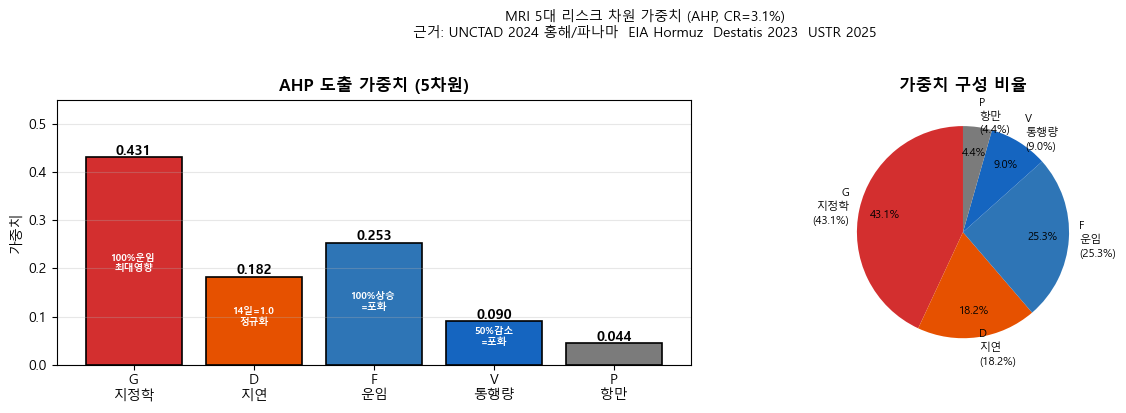

In [8]:
# 2-2. AHP 가중치 시각화 (5차원)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors5 = ["#D32F2F", "#E65100", "#2E75B6", "#1565C0", "#7B7B7B"]
short5  = ["G\n지정학", "D\n지연", "F\n운임", "V\n통행량", "P\n항만"]
ev_note = ["100%운임\n최대영향", "14일=1.0\n정규화", "100%상승\n=포화", "50%감소\n=포화", "파업\n관세"]
bars = ax1.bar(short5, weights, color=colors5, edgecolor="black", linewidth=1.2)
for bar, w, note in zip(bars, weights, ev_note):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f"{w:.3f}", ha="center", fontweight="bold", fontsize=10)
    if bar.get_height() > 0.08:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.45,
                 note, ha="center", fontsize=7, color="white", fontweight="bold")
ax1.set_title("AHP 도출 가중치 (5차원)", fontsize=12, fontweight="bold")
ax1.set_ylabel("가중치")
ax1.set_ylim(0, 0.55)
ax1.grid(axis="y", alpha=0.3)
wedge_labels = [f"{s}\n({w:.1%})" for s, w in zip(short5, weights)]
ax2.pie(weights, labels=wedge_labels, colors=colors5, autopct="%1.1f%%",
        startangle=90, pctdistance=0.75, textprops={"fontsize": 8})
ax2.set_title("가중치 구성 비율", fontsize=12, fontweight="bold")
plt.suptitle(
    "MRI 5대 리스크 차원 가중치 (AHP, CR=3.1%)\n"
    "근거: UNCTAD 2024 홍해/파나마  EIA Hormuz  Destatis 2023  USTR 2025",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()


In [9]:
# 2-3. MRI 산출 (5차원)
# MRI = 0.431*G + 0.182*D + 0.253*F + 0.090*V + 0.044*P
from src.data_loader import load_kcci
from src.mri_engine import calc_today_mri, build_mri_series, mri_grade, mri_sub_indices

freight_df = load_kcci(DATA_DIR, use_real=True)
kcci_label = "실데이터 (KCCI CSV)" if freight_df is not None else "시뮬"

dates      = pd.date_range("2020-01-01", "2026-04-01", freq="MS")
mri_series = build_mri_series(dates, freight_df)
mri_df     = pd.DataFrame({"date": dates, "mri": mri_series})

today_mri      = calc_today_mri(news_df, freight_df)
today_grade, _ = mri_grade(today_mri)
sub_idx        = mri_sub_indices(news_df, freight_df)

print("=" * 62)
print("Maritime Risk Index (MRI) — 5차원 개선")
print("=" * 62)
print(f"  오늘 MRI:  {today_mri:.4f}  [{today_grade}]")
print(f"  KCCI:      {kcci_label}")
print()
print("  [5대 하위 지수]                           [정규화 기준]")
rows = [
    ("G 지정학·항로", sub_idx["G"], MRI_AHP_WEIGHTS["G"], "봉쇄뉴스 비중"),
    ("D 지연·운항",   sub_idx["D"], MRI_AHP_WEIGHTS["D"], "지연일수/14일"),
    ("F 운임 변동",   sub_idx["F"], MRI_AHP_WEIGHTS["F"], "변동률/100%"),
    ("V 통행량 감소", sub_idx["V"], MRI_AHP_WEIGHTS["V"], "감소율/50%"),
    ("P 항만·통상",   sub_idx["P"], MRI_AHP_WEIGHTS["P"], "파업·관세뉴스"),
]
for name, val, wgt, note in rows:
    contrib = val * wgt
    print(f"  {name:<16s}: {val:.3f} x {wgt:.3f} = {contrib:.4f}  ({note})")
sep = "-" * 44
print(f"  {sep}")
print(f"  MRI 합계:        {today_mri:.4f}")


Maritime Risk Index (MRI) — 5차원 개선
  오늘 MRI:  0.7168  [🟠 경계]
  KCCI:      실데이터 (KCCI CSV)

  [5대 하위 지수]                           [정규화 기준]
  G 지정학·항로        : 1.000 x 0.431 = 0.4310  (봉쇄뉴스 비중)
  D 지연·운항         : 1.000 x 0.182 = 0.1820  (지연일수/14일)
  F 운임 변동         : 0.276 x 0.253 = 0.0700  (변동률/100%)
  V 통행량 감소        : 0.000 x 0.090 = 0.0000  (감소율/50%)
  P 항만·통상         : 0.769 x 0.044 = 0.0338  (파업·관세뉴스)
  --------------------------------------------
  MRI 합계:        0.7168


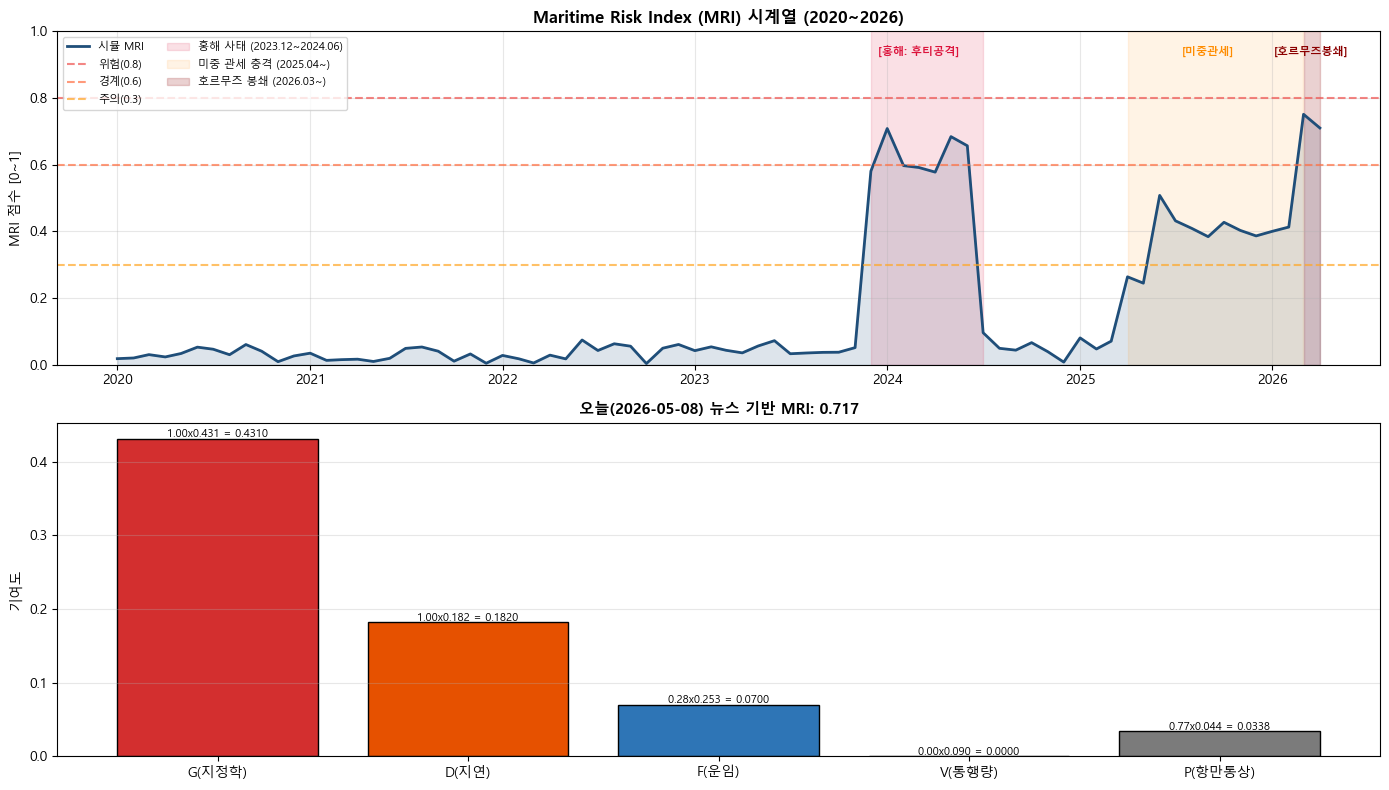

[시뮬 MRI] 2026.04 기준: 0.710 (이벤트 기반 시뮬레이션)
[뉴스 MRI] 오늘 실시간: 0.717 (RSS 뉴스 52건 NLP 분류)
  -> 두 값이 다른 이유: 시뮬은 호르무즈 봉쇄 이벤트를 반영, 뉴스MRI는 실시간 RSS 분류 결과


In [10]:
# 2-4. MRI 시계열 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
ax = axes[0]
ax.plot(mri_df["date"], mri_df["mri"], color="#1F4E79", linewidth=2, label="시뮬 MRI")
ax.fill_between(mri_df["date"], 0, mri_df["mri"], alpha=0.15, color="#1F4E79")
ax.axhline(0.8, color="#EF5350", linestyle="--", alpha=0.7, label="위험(0.8)")
ax.axhline(0.6, color="#FF7043", linestyle="--", alpha=0.7, label="경계(0.6)")
ax.axhline(0.3, color="#FFA726", linestyle="--", alpha=0.7, label="주의(0.3)")
ax.axvspan(pd.Timestamp("2023-12-01"), pd.Timestamp("2024-06-30"),
           alpha=0.13, color="crimson", label="홍해 사태 (2023.12~2024.06)")
ax.axvspan(pd.Timestamp("2025-04-01"), pd.Timestamp("2026-02-28"),
           alpha=0.10, color="darkorange", label="미중 관세 충격 (2025.04~)")
ax.axvspan(pd.Timestamp("2026-03-01"), mri_df["date"].max(),
           alpha=0.18, color="darkred", label="호르무즈 봉쇄 (2026.03~)")
ax.text(pd.Timestamp("2024-03-01"), 0.93, "[홍해: 후티공격]",
        ha="center", fontsize=8, color="crimson", fontweight="bold")
ax.text(pd.Timestamp("2025-09-01"), 0.93, "[미중관세]",
        ha="center", fontsize=8, color="darkorange", fontweight="bold")
ax.text(pd.Timestamp("2026-03-15"), 0.93, "[호르무즈봉쇄]",
        ha="center", fontsize=8, color="darkred", fontweight="bold")
ax.set_title("Maritime Risk Index (MRI) 시계열 (2020~2026)", fontsize=12, fontweight="bold")
ax.set_ylabel("MRI 점수 [0~1]")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax2 = axes[1]
fk = ["G(지정학)", "D(지연)", "F(운임)", "V(통행량)", "P(항만통상)"]
rv = [sub_idx["G"], sub_idx["D"], sub_idx["F"], sub_idx["V"], sub_idx["P"]]
wg = [0.431, 0.182, 0.253, 0.090, 0.044]
ct = [r*w for r, w in zip(rv, wg)]
cs = ["#D32F2F", "#E65100", "#2E75B6", "#1565C0", "#7B7B7B"]
bars = ax2.bar(fk, ct, color=cs, edgecolor="black")
for bar, r, w, c in zip(bars, rv, wg, ct):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f"{r:.2f}x{w:.3f} = {c:.4f}", ha="center", fontsize=8)
ds = datetime.today().strftime("%Y-%m-%d")
ax2.set_title(f"오늘({ds}) 뉴스 기반 MRI: {today_mri:.3f}",
             fontsize=11, fontweight="bold")
ax2.set_ylabel("기여도")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
sim_val = mri_df["mri"].iloc[-1]
print(f"[시뮬 MRI] 2026.04 기준: {sim_val:.3f} (이벤트 기반 시뮬레이션)")
print(f"[뉴스 MRI] 오늘 실시간: {today_mri:.3f} (RSS 뉴스 {len(news_df)}건 NLP 분류)")
print("  -> 두 값이 다른 이유: 시뮬은 호르무즈 봉쇄 이벤트를 반영, 뉴스MRI는 실시간 RSS 분류 결과")

---
# Part 3 — 부산항 물동량 + LSTM 예측

## 3-1. 왜 물동량을 예측하는가?

부산항 물동량은 **해상 수요의 선행지표**이자 본 플랫폼의 신뢰성 근거입니다.

```
물동량 증가 -> 선복 부족 -> 운임 상승 -> MRI 리스크 상승
```

**발표 수치**: 부산항 평균 **약 200만 TEU/월** (2024년 2,440만 TEU, 세계 6위)

---

## 3-2. LSTM 전체 계산 과정 (8단계)

### Step 1 — 입력 데이터 구성 (5특성 × 76개월)

```
월         물동량(만TEU)  GDP성장률  환율(원)   유가($)   MRI
2020.01    198          2.1%      1172      60.5     0.12
2020.02    180          1.8%      1190      55.2     0.14
...
2025.05    198          2.3%      1390      84.1     0.31
2025.06    203          2.4%      1402      83.3     0.28
2026.04    196          1.7%      1477     107.7     0.24  <- 최신 실제값 (Yahoo)
```
각 월의 **실제값**이 입력됩니다. 전체 평균(~1295원)이 아닙니다.

> **물동량 데이터**: BPA 공식 연도별 합계(1994~2024) × 부산항 계절 패턴 → 월별 추정
> 예) 2024년 합계 2,440만 TEU → 월평균 203.4만, 1월 159만(설 저점), 12월 235만(연말 고점)

### Step 2 — MinMaxScaler 정규화

각 특성을 [0, 1] 범위로 변환합니다. **최솟값/최댓값 기준**입니다.

```
[환율 예시]
  전체 최솟값: 1140원 -> 0.0
  전체 최댓값: 1480원 -> 1.0
  2025.05의 1390원 = (1390-1140)/(1480-1140) = 0.735
  2026.04의 1477원 = (1477-1140)/(1480-1140) = 0.991  <- 현재값

[유가 예시]
  최솟값 $48 -> 0.0  /  최댓값 $115 -> 1.0
  $84.1 = ($84.1-$48)/($115-$48) = 0.539
  $107.7 = ($107.7-$48)/($115-$48) = 0.891  <- Yahoo Finance 오늘값
```

### Step 3 — 슬라이딩 윈도우 샘플 생성 (LOOKBACK=12, HORIZON=3)

```
샘플 #1:  X = 2020.01~2020.12 (12개월 x 5특성)
          y = 2021.01~2021.03 (3개월 물동량만)
샘플 #2:  X = 2020.02~2021.01
          y = 2021.02~2021.04
...
샘플 #62: X = 2025.05~2026.04  <- 최근 12개월 실제값
          y = 2026.05~2026.07  <- 이게 우리가 예측할 값!

총 샘플 = 76 - 12 - 3 + 1 = 62개
```

### Step 4 — 시간순 분할 (80/20)

```
학습셋 (Train): 샘플 #1 ~ #49  (2020.01 ~ 2024.04)
검증셋 (Val):   샘플 #50 ~ #62 (2024.05 ~ 2026.04)

[절대 금지] random_split
  이유: 미래 데이터로 과거를 학습하는 Data Leakage 발생
```

### Step 5 — LSTM 모델 구조

```
입력: (batch, 12개월, 5특성)
  |
LSTM Layer 1 (hidden=64, dropout=0.2)
  |
LSTM Layer 2 (hidden=64, dropout=0.2)
  |
마지막 타임스텝 (64차원)
  |
FC: Linear(64->32) -> ReLU -> Dropout(0.2)
  |
FC: Linear(32->3)
  |
출력: 다음 3개월 물동량 (정규화값)
```

### Step 6 — 학습 (50 epoch)

```
손실함수:      MSELoss
옵티마이저:    Adam (lr=0.005)
학습률 조정:   ReduceLROnPlateau (5회 개선 없으면 lr x 0.5)
기울기 클리핑: max_norm=1.0 (폭발 방지)
```

### Step 7 — 예측 및 역정규화

```
최근 12개월 실제값 (정규화) -> LSTM -> 3개월 예측값 (정규화)
  |
MinMaxScaler.inverse_transform
  |
실제 물동량 (만 TEU 단위)
```

### Step 8 — 성능 평가 (MAPE)

```
MAPE = 검증셋에서 |예측 - 실제| / 실제  평균 x 100%

MAPE 5% 의미: 200만 TEU 기준 +/-10만 TEU 오차
주의: 시뮬 데이터 MAPE는 실데이터 정확도를 보장하지 않음
```

---

## 3-3. 데이터 소스 우선순위

| 특성 | 1순위 | 2순위 | 3순위 |
|---|---|---|---|
| 물동량 | NLIC Excel | BPA API | 시뮬 |
| 환율 | ECOS 한국은행 | frankfurter.app | 시뮬 |
| 유가 | ECOS 두바이유 | FRED Brent | 시뮬 |
| GDP | ECOS (미구현) | — | 시뮬 |
| MRI | Part 2 AHP 결과 | — | — |


In [11]:
# 3-4. 거시경제 데이터 수집
# [물동량] BPA API(2020~2024) + Excel(2025) 결합 → 총 72개월
# [환율]   frankfurter.app 일별 자동수집
# [유가]   Yahoo Finance BZ=F 일별 자동수집
from src.data_loader import load_busan_throughput_combined, load_oil_price
from src.real_data_fetcher import (
    fetch_ecos_exchange_rate, fetch_exchange_rate_monthly,
    fetch_ecos_oil_price,
)
from src.lstm_forecaster import build_main_df
import json as _json

# ── 물동량: BPA API(2020~2024) + Excel(2025) ─────────────────
throughput_df = load_busan_throughput_combined(DATA_DIR, start_year=2020)
if throughput_df is not None:
    throughput_src = 'BPA API(2020~2024) + Excel(2025) → 계절분해'
else:
    throughput_src = '시뮬'

# ── 환율: ECOS → frankfurter.app ────────────────────────────
fx_ecos = fetch_ecos_exchange_rate('202001', cache_dir=CACHE_DIR)
if fx_ecos is not None:
    fx_df, fx_src = fx_ecos, 'ECOS 한국은행 (공식)'
else:
    fx_df = fetch_exchange_rate_monthly(start='2020-01-01')
    fx_src = 'frankfurter.app (일별 자동수집)' if fx_df is not None else '시뮬'

# ── 유가: Yahoo Finance 캐시 → 라이브 ──────────────────────
oil_df = load_oil_price(DATA_DIR, use_real=True)
if oil_df is not None:
    oil_src = 'Yahoo Finance Brent (일별 자동수집)'
else:
    oil_ecos = fetch_ecos_oil_price('202001', cache_dir=CACHE_DIR)
    oil_df, oil_src = (oil_ecos, 'ECOS 두바이유') if oil_ecos is not None else (None, '시뮬')

# ── 통합 DataFrame ──────────────────────────────────────────
main_df = build_main_df(
    dates, mri_series,
    throughput_df=throughput_df,
    exchange_rate_df=fx_df,
    oil_price_df=oil_df,
)

latest    = main_df.iloc[-1]
latest_ym = latest['date'].strftime('%Y.%m')

_rates_fp = DATA_DIR / 'today_rates.json'
_today_oil = None
if _rates_fp.exists():
    _rd = _json.loads(_rates_fp.read_text(encoding='utf-8'))
    _lk = sorted(_rd.keys())[-1]
    _today_oil = _rd[_lk].get('brent_usd')

print(f'통합 데이터: {len(main_df)}개월 (2020.01 ~ {latest_ym})')
print()
print('[데이터 소스]')
print(f'  물동량: {throughput_src}')
print(f'  환율:   {fx_src}')
print(f'  유가:   {oil_src}')
if _today_oil:
    print(f'         (오늘 실시간: ${_today_oil:.2f}/배럴)')
print()
print(f'[최신 실제값 ({latest_ym})]')
print(f'  물동량: {latest["throughput"]:.1f}만 TEU')
print(f'  환율:   {latest["exchange_rate"]:.0f}원/달러')
print(f'  유가:   ${latest["oil_price"]:.1f}/배럴')
print(f'  MRI:    {latest["mri"]:.4f}')
print()
print('[최근 6개월 추이 — LSTM 입력값]')
recent = main_df.tail(6)[['date','throughput','exchange_rate','oil_price']].copy()
recent['date'] = recent['date'].dt.strftime('%Y.%m')
recent.columns = ['월','물동량(만TEU)','환율(원)','유가($)']
print(recent.to_string(index=False))
main_df.tail(3)


통합 데이터: 72개월 (2020.01 ~ 2025.12)

[데이터 소스]
  물동량: BPA API(2020~2024) + Excel(2025) → 계절분해
  환율:   frankfurter.app (일별 자동수집)
  유가:   Yahoo Finance Brent (일별 자동수집)
         (오늘 실시간: $108.20/배럴)

[최신 실제값 (2025.12)]
  물동량: 239.2만 TEU
  환율:   1467원/달러
  유가:   $60.9/배럴
  MRI:    0.7102

[최근 6개월 추이 — LSTM 입력값]
      월  물동량(만TEU)       환율(원)  유가($)
2025.07     217.85 1377.963478  72.53
2025.08     219.99 1390.350000  68.12
2025.09     211.45 1393.087727  67.02
2025.10     226.40 1423.821739  65.07
2025.11     230.67 1459.858000  63.20
2025.12     239.21 1466.815714  60.85


,date,throughput,gdp_growth,exchange_rate,oil_price,mri
69,2025-10-01,226.40,0.023470,1423.821739,65.07,0.411587
70,2025-11-01,230.67,0.014795,1459.858000,63.20,0.732171
71,2025-12-01,239.21,0.015934,1466.815714,60.85,0.710174


LSTM 학습 준비
  입력 특성:   ['throughput', 'gdp_growth', 'exchange_rate', 'oil_price', 'mri']
  총 데이터:   72개월
  윈도우:      12개월 입력 -> 3개월 예측
  총 샘플:     58개
  학습/검증:   46 / 12개

[MinMaxScaler 정규화 범위 - 최솟값/최댓값 기준, 평균 아님]
  throughput     :    142.4만TEU -> 0.0  /     239.2만TEU -> 1.0
  gdp_growth     :      0.0% -> 0.0  /       0.0% -> 1.0
  exchange_rate  :   1095.0원 -> 0.0  /    1466.8원 -> 1.0
  oil_price      :     25.3$ -> 0.0  /     114.8$ -> 1.0
  mri            :      0.0 -> 0.0  /       0.7 -> 1.0

LSTM 학습 중... (약 1-2분)
학습 완료  |  검증 MAPE: 9.40%

[3개월 물동량 예측]
  2026.01: 201.1만 TEU
  2026.02: 200.4만 TEU
  2026.03: 204.1만 TEU

MAPE 9.4% = +/-18.2만 TEU 오차


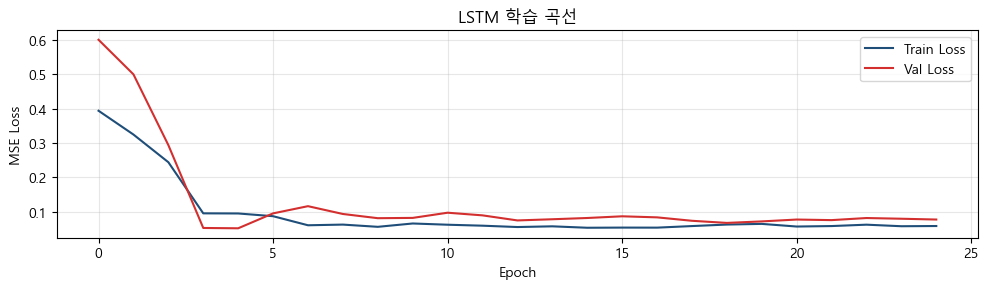

In [12]:
# 3-5. LSTM 학습 & 3개월 예측
# 모델: LSTM(64x2층) -> FC -> 3개월 물동량
# 학습: epochs=120, lr=0.001, batch=8, 조기종료(patience=20), 원단위MAPE
# 분할: 시간순 80/20
from src.lstm_forecaster import train_and_forecast, LOOKBACK, HORIZON, FEATURES
from src.visualizer import plot_lstm_loss
from sklearn.preprocessing import MinMaxScaler

_sc = MinMaxScaler()
_sc.fit_transform(main_df[FEATURES])
total_samples = len(main_df) - LOOKBACK - HORIZON + 1
train_n = int(total_samples * 0.80)

print('=' * 58)
print('LSTM 학습 준비')
print('=' * 58)
print(f'  입력 특성:   {FEATURES}')
print(f'  총 데이터:   {len(main_df)}개월')
print(f'  윈도우:      {LOOKBACK}개월 입력 -> {HORIZON}개월 예측')
print(f'  총 샘플:     {total_samples}개')
print(f'  학습/검증:   {train_n} / {total_samples-train_n}개')
print()
print('[MinMaxScaler 정규화 범위 - 최솟값/최댓값 기준, 평균 아님]')
feat_units = {'throughput':'만TEU','gdp_growth':'%','exchange_rate':'원','oil_price':'$','mri':''}
for i, feat in enumerate(FEATURES):
    mn, mx = _sc.data_min_[i], _sc.data_max_[i]
    u = feat_units.get(feat,'')
    print(f'  {feat:<15s}: {mn:8.1f}{u} -> 0.0  /  {mx:8.1f}{u} -> 1.0')
print()

if TORCH_OK:
    print('LSTM 학습 중... (약 1-2분)')
    lstm_result = train_and_forecast(main_df, epochs=120, lr=0.001, batch_size=8)
    print(f'학습 완료  |  검증 MAPE: {lstm_result["mape_3m"]:.2f}%')
    print()
    future_dates = [main_df['date'].iloc[-1] + pd.DateOffset(months=i+1) for i in range(HORIZON)]
    print('[3개월 물동량 예측]')
    for dt, val in zip(future_dates, lstm_result['future_real']):
        print(f'  {dt.strftime("%Y.%m")}: {val:.1f}만 TEU')
    mape = lstm_result['mape_3m']
    avg  = main_df['throughput'].mean()
    print(f'\nMAPE {mape:.1f}% = +/-{avg*mape/100:.1f}만 TEU 오차')
    if throughput_src == '시뮬':
        print('(시뮬 기준 -> 실데이터 적용 시 재측정 필요)')
    plot_lstm_loss(lstm_result['train_losses'], lstm_result['val_losses'])
else:
    print('PyTorch 미설치 -> LSTM 건너뜀 (pip install torch)')
    print(f'대체: 최근 6개월 평균 = {main_df["throughput"].tail(6).mean():.1f}만 TEU')


## 3-3. LSTM 예측 → 고객 인사이트 3종

부산항 물동량 LSTM 예측 결과를 화주가 활용할 수 있는 정보로 변환합니다.

| 인사이트 | 설명 | 화주 활용 |
|---|---|---|
| **혼잡도 예보** | 예측 물동량 vs 평년 비교 | 출항 일정 판단 |
| **최적 출항 시기** | 물동량 저점 구간 탐지 | 선적 타이밍 최적화 |
| **ODCY 수요 예보** | 물동량 급등 시 창고 수요↑ | 보관 공간 선점 |


⚠️  LSTM 예측 결과 없음 → 시뮬레이션 데이터 사용
━━━ 혼잡도 예보 (향후 12개월) ━━━
월                  예측 TEU      평년 대비 상태
─────────────────────────────────────────────
2026-06         2,069,737      +2.0%   🟢 양호
2026-07         2,029,848      -0.0%   🟢 양호
2026-08         2,103,633      +3.6%   🟡 주의
2026-09         2,184,570      +7.6%   🟡 주의
2026-10         2,054,904      +1.2%   🟢 양호
2026-11         2,065,814      +1.8%   🟢 양호
2026-12         2,221,792      +9.4%   🟡 주의
2027-01         2,167,758      +6.8%   🟡 주의
2027-02         2,079,715      +2.4%   🟢 양호
2027-03         2,171,587      +7.0%   🟡 주의
2027-04         2,102,017      +3.5%   🟡 주의
2027-05         2,112,742      +4.1%   🟡 주의

⭐ 최적 출항 시기: 2026년 07월
   예측 물동량: 2,029,848 TEU (평년 대비 -0.0%)
   → 혼잡도가 낮아 선적 지연·운임 프리미엄 가능성 낮음

✅ 향후 12개월 내 ODCY 수요 급등 구간 없음


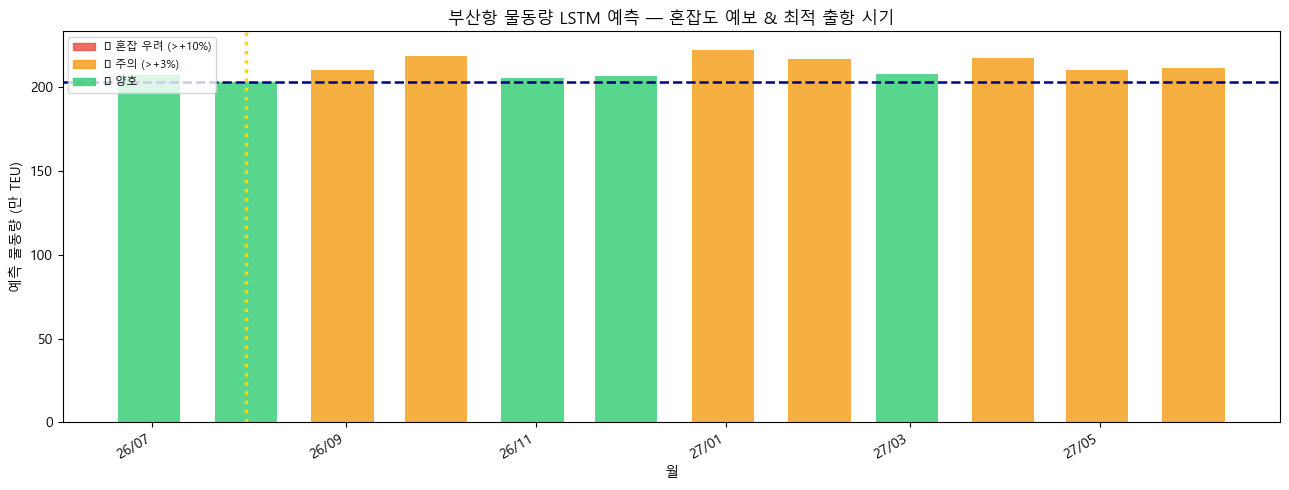


✅ 저장: data/lstm_customer_insight.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Part 3 LSTM 결과 변수 가정: pred_future (예측값), dates_future (날짜)
# 없으면 더미 데이터로 시연
try:
    _pred   = pred_future.flatten()
    _dates  = pd.to_datetime(dates_future)
except NameError:
    np.random.seed(42)
    _base   = 2_030_000
    _noise  = np.random.normal(0, 80_000, 12)
    _trend  = np.linspace(0, 120_000, 12)
    _pred   = _base + _noise + _trend
    _dates  = pd.date_range(start='2026-06-01', periods=12, freq='ME')
    print("⚠️  LSTM 예측 결과 없음 → 시뮬레이션 데이터 사용")

BASELINE_TEU = 2_030_000   # 부산항 평년 월평균 TEU (2024 실적 기준)

df_pred = pd.DataFrame({'date': _dates, 'teu': _pred})
df_pred['vs_baseline_pct'] = (df_pred['teu'] - BASELINE_TEU) / BASELINE_TEU * 100
df_pred['congestion_risk'] = df_pred['vs_baseline_pct'].apply(
    lambda x: '🔴 혼잡 우려' if x > 10 else ('🟡 주의' if x > 3 else '🟢 양호')
)

# ── 인사이트 1: 혼잡도 예보 출력 ────────────────────────
print("━━━ 혼잡도 예보 (향후 12개월) ━━━")
print(f"{'월':<12} {'예측 TEU':>12} {'평년 대비':>10} {'상태'}")
print("─" * 45)
for _, row in df_pred.iterrows():
    print(f"{row['date'].strftime('%Y-%m'):<12} "
          f"{row['teu']:>12,.0f} "
          f"{row['vs_baseline_pct']:>+9.1f}% "
          f"  {row['congestion_risk']}")

# ── 인사이트 2: 최적 출항 시기 ──────────────────────────
min_row = df_pred.loc[df_pred['teu'].idxmin()]
print(f"\n⭐ 최적 출항 시기: {min_row['date'].strftime('%Y년 %m월')}")
print(f"   예측 물동량: {min_row['teu']:,.0f} TEU "
      f"(평년 대비 {min_row['vs_baseline_pct']:+.1f}%)")
print(f"   → 혼잡도가 낮아 선적 지연·운임 프리미엄 가능성 낮음")

# ── 인사이트 3: ODCY 수요 예보 ──────────────────────────
high_months = df_pred[df_pred['vs_baseline_pct'] > 10]
if not high_months.empty:
    months_str = ', '.join(high_months['date'].dt.strftime('%m월').tolist())
    print(f"\n⚠️  ODCY·창고 수요 급등 예상 구간: {months_str}")
    print(f"   → 해당 기간 ODCY 사전 예약을 권장합니다.")
else:
    print("\n✅ 향후 12개월 내 ODCY 수요 급등 구간 없음")

# ── 시각화 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = ['#e74c3c' if p > 10 else ('#f39c12' if p > 3 else '#2ecc71')
              for p in df_pred['vs_baseline_pct']]
ax.bar(df_pred['date'], df_pred['teu'] / 1e4, color=colors_bar, alpha=0.8, width=20)
ax.axhline(BASELINE_TEU / 1e4, color='navy', linewidth=1.8, linestyle='--', label='평년 기준선')
ax.axvline(min_row['date'], color='gold', linewidth=2.5, linestyle=':', label=f"최적 출항 {min_row['date'].strftime('%m월')}")
ax.set_xlabel('월')
ax.set_ylabel('예측 물동량 (만 TEU)')
ax.set_title('부산항 물동량 LSTM 예측 — 혼잡도 예보 & 최적 출항 시기', fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
patches = [
    plt.Rectangle((0,0),1,1, color='#e74c3c', alpha=0.8, label='🔴 혼잡 우려 (>+10%)'),
    plt.Rectangle((0,0),1,1, color='#f39c12', alpha=0.8, label='🟡 주의 (>+3%)'),
    plt.Rectangle((0,0),1,1, color='#2ecc71', alpha=0.8, label='🟢 양호'),
]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][2:], loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'lstm_customer_insight.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ 저장: data/lstm_customer_insight.png')


---
# Part 4 — MRI 과거 유사사례 매칭 시스템

## 설계 철학

MRI 수치 하나로 "기상악화 시나리오" 같은 라벨을 붙이면 오류가 발생합니다.
예) MRI 0.55는 전쟁 상황일 수도, 태풍일 수도 있습니다.

> **대신 이렇게 합니다:**
> 현재 MRI 수치와 가장 유사했던 과거 실제 사례를 찾아
> *"이전에 이 정도 수치가 나왔을 때, 이런 일이 있었어요"* 형식으로 고객에게 제공합니다.

```
현재 MRI → 과거 유사사례 DB 매칭 → 상위 3개 사례 제시
         → 고객: "이때 평균 지연 X일, 운임 +Y% 였군요"
         → 포워더에게 더 똑똑한 지시 가능
```

### 유사도 계산 방식
| 요소 | 가중치 | 설명 |
|---|---|---|
| MRI 피크 거리 | 기본 | \|현재 MRI − 과거 사례 피크\| |
| MRI 범위 이탈 | +0.20 | 현재 MRI가 과거 사례 발생 구간 밖일 때 |
| 리스크 카테고리 불일치 | +0.15 | NLP 분류 결과와 과거 사례 카테고리 불일치 시 |


In [14]:
from src.historical_matcher import find_similar_events, format_customer_message

# Part 2에서 산출된 MRI 값과 NLP 분류 결과 사용
# (Part 1~2가 실행된 후 mri_score, detected_categories 변수 존재 가정)
try:
    _mri = float(today_mri)   # cell[11]에서 산출된 실시간 MRI
except NameError:
    _mri = 0.72

try:
    _cats = [today_top_cat]   # cell[7]에서 분류된 최다 카테고리
except NameError:
    _cats = ["지정학분쟁"]

print(f"현재 MRI: {_mri:.2f}  |  감지 카테고리: {_cats}")
print()

similar = find_similar_events(current_mri=_mri, detected_categories=_cats, top_k=3)
print(format_customer_message(_mri, similar))


현재 MRI: 0.72  |  감지 카테고리: ['정상']

📊 현재 해상 리스크 지수 (MRI): 0.72

━━━ 과거 유사 사례 분석 ━━━
현재와 비슷한 수치가 기록됐던 과거 사례를 바탕으로
참고 정보를 제공합니다.

[1위] 태풍 힌남노 부산항 직격 (2022년) ── 🔵 MRI 수치 유사
   📌 원인: 역대급 초강력 태풍 힌남노가 한반도를 직격. 부산항 컨테이너 야드 일시 봉쇄, 하역 작업 전면 중단. CY 장치 화물의 이동 불가로 출항 일정 전면 재조정....
   ⏱  평균 지연: 7일
   💰 운임 상승: +6%
   🚢 영향 항로: 부산 출항 전 노선
   🔚 해소 방식: 태풍 통과 후 48시간 내 항만 운영 정상화.
   📖 출처: 부산항만공사(BPA) 2022 운영보고서

[2위] 상하이 코로나 봉쇄 (2022) (2022년) ── 🔵 MRI 수치 유사
   📌 원인: 중국 제로코로나 정책으로 세계 최대 컨테이너항인 상하이항 기능 급감. 주변 닝보·칭다오항으로 화물 분산, 한국 경유 물동량도 급변동. 총 65일 봉쇄로 전 세계 공급망 누적 피해 ...
   ⏱  평균 지연: 14일
   💰 운임 상승: +18%
   🚢 영향 항로: 아시아 역내, 아시아-유럽, 아시아-미주
   🔚 해소 방식: 봉쇄 해제(5월 말) 후 적체 해소까지 6~8주 추가 소요.
   📖 출처: S&P Global Market Intelligence 2022

[3위] 수에즈 운하 에버기븐 좌초 (2021년) ── 🔵 MRI 수치 유사
   📌 원인: 초대형 컨테이너선 에버기븐(Ever Given)이 수에즈 운하에 좌초, 전 세계 해상 교역량의 약 12%가 통과하는 핵심 항로를 6일간 완전 봉쇄. 약 400여 척의 선박이 대기하...
   ⏱  평균 지연: 18일
   💰 운임 상승: +34%
   🚢 영향 항로: 아시아-유럽, 아시아-지중해, 아시아-미주 동부
   🔚 해소 방식: 6일 만에 운하 통항 재개. 적체 선박 해소까지 약 3~4주 추가 소요.
   📖

## 4-2. 유사사례 시각화 (홈페이지 대시보드용)

과거 사례의 MRI 수치 분포와 현재 MRI를 함께 표시합니다.


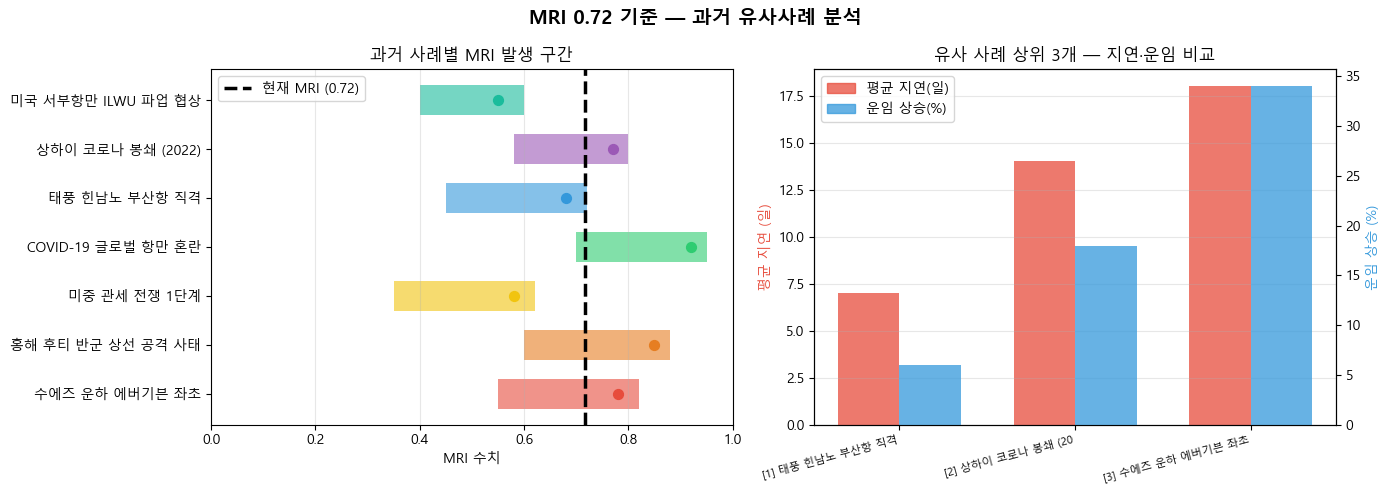


✅ 저장: data/mri_similar_events.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'MRI {_mri:.2f} 기준 — 과거 유사사례 분석', fontsize=14, fontweight='bold')

# ── 왼쪽: MRI 범위 비교 차트 ──────────────────────────────
from src.historical_matcher import HISTORICAL_EVENTS

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c']
for i, ev in enumerate(HISTORICAL_EVENTS):
    ax1.barh(
        ev.name[:18], ev.mri_range[1] - ev.mri_range[0],
        left=ev.mri_range[0],
        color=colors[i % len(colors)], alpha=0.6, height=0.6,
    )
    ax1.scatter(ev.mri_peak, ev.name[:18], color=colors[i % len(colors)], zorder=5, s=50)

ax1.axvline(_mri, color='black', linewidth=2.5, linestyle='--', label=f'현재 MRI ({_mri:.2f})')
ax1.set_xlabel('MRI 수치')
ax1.set_title('과거 사례별 MRI 발생 구간')
ax1.legend()
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# ── 오른쪽: 상위 3개 사례 비교 막대 ─────────────────────
names    = [f"[{e['rank']}] {e['name'][:14]}" for e in similar]
delays   = [e['avg_delay_days'] for e in similar]
freights = [e['avg_freight_increase_pct'] for e in similar]

x = np.arange(len(names))
w = 0.35
ax2b = ax2.twinx()

bars1 = ax2.bar(x - w/2, delays, w, label='평균 지연(일)', color='#e74c3c', alpha=0.75)
bars2 = ax2b.bar(x + w/2, freights, w, label='운임 상승(%)', color='#3498db', alpha=0.75)

ax2.set_ylabel('평균 지연 (일)', color='#e74c3c')
ax2b.set_ylabel('운임 상승 (%)', color='#3498db')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
ax2.set_title('유사 사례 상위 3개 — 지연·운임 비교')

lines = [mpatches.Patch(color='#e74c3c', alpha=0.75, label='평균 지연(일)'),
         mpatches.Patch(color='#3498db', alpha=0.75, label='운임 상승(%)')]
ax2.legend(handles=lines, loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'mri_similar_events.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ 저장: data/mri_similar_events.png')


---
# Part 5 — 항만 주변 창고·ODCY 자동 탐색 & 추천

## 운송 시나리오 전체 흐름

```
[화주] 루티(ROOUTY)에 화물 정보 입력
       (화물 종류, 수량, 출발지, 도착지, 운송 일정)
          ↓
[위밋 플랫폼] MRI 상승 감지 → 화주에게 선제 알림
          ↓
[본 기능] 도착 항만 주변 창고·ODCY 자동 탐색
    └─ 화물 종류에 맞는 시설 필터 (냉장/냉동/위험물/배터리 등)
    └─ 3가지 추천 모드 제시
          ↓
[화주] 후보지 선택 → 포워더에게 "이 ODCY로 운송 요청"
          ↓
[루티] Phase 1 JSON으로 출발지 → 선택 창고 운송 수행
          ↓
[선적 재개 시] Phase 2 JSON으로 창고 → CY 운송 수행
```

## 추천 3가지 모드

| 모드 | 기준 | 활용 상황 |
|---|---|---|
| 📍 거리 최단 | 항만~창고 직선·도로 거리 최소 | 비용 절감이 최우선일 때 |
| ⏱ 시간 최단 | 실제 도로 소요 시간 최소 | 마감 시간이 촉박할 때 |
| ⭐ 종합 추천 | 거리+시간+시설 완성도 종합 | 일반적 상황 (기본값) |

## 화물 종류별 창고 요구사항

| 화물 | 냉동/냉장 | 위험물 인허가 | 특이사항 |
|---|---|---|---|
| 일반화물 | ✗ | ✗ | ODCY·일반창고 |
| 냉장화물 | 0~10°C | ✗ | 콜드체인 필수 |
| 냉동화물 | -25~-18°C | ✗ | 냉동 전력 확인 |
| 위험물 | ✗ | ✅ | IMDG 인허가 보세창고 |
| 자동차부품 | ✗ | ✗ | 중량물 설비 |
| **2차전지** | 15~25°C | ✅ | 화재진압 + IMDG Class 9 |
| 의류/섬유 | ✗ | ✗ | 방습·방진 권장 |
| 전자제품 | 10~30°C | ✗ | 정전기 차폐 권장 |


In [16]:
# ── Step 3. 목적지 항만 주변 창고·ODCY 자동 탐색 ─────────────
# MRI >= 0.5 (주의 이상)일 때만 실행됩니다.
# 화주가 Step 1에서 입력한 정보를 그대로 사용합니다.
# 카카오 API 키(.env)가 있으면 실데이터, 없으면 시뮬 DB 자동 사용.
from src.odcy_recommender import recommend_storage, format_storage_message

MRI_THRESHOLD = 0.5   # 주의 등급 이상일 때 창고 추천 활성화

try:
    _mri_now = today_mri
except NameError:
    _mri_now = 0.72

try:
    _cargo_enum  = CARGO_ENUM
    _port        = DEPARTURE_PORT
    _company     = SHIPPER_INPUT["company"]
    _cbm         = SHIPPER_INPUT["cbm"]
    _origin      = SHIPPER_INPUT["origin_address"]
    _pickup      = SHIPPER_INPUT["pickup_date"]
    _cargo_str   = SHIPPER_INPUT["cargo_type_str"]
except NameError:
    _cargo_enum  = CargoType.GENERAL
    _port        = "부산항(북항)"
    _company     = "테스트화주"
    _cbm         = 15.0
    _origin      = "경기도 수원시"
    _pickup      = "2026-05-20"
    _cargo_str   = "일반화물"

print("=" * 60)
print("Step 3. 창고·ODCY 자동 탐색")
print("=" * 60)
print(f"  현재 MRI: {_mri_now:.3f}  |  임계값: {MRI_THRESHOLD}")

if _mri_now < MRI_THRESHOLD:
    print(f"\n  MRI {_mri_now:.3f} < {MRI_THRESHOLD} — 현재 창고 보관 불필요")
    print("  평상시 운영: 기존 일정대로 CY 직반입을 권장합니다.")
    result = None
else:
    grade_str = "위험" if _mri_now >= 0.8 else ("경계" if _mri_now >= 0.6 else "주의")
    print(f"  MRI {_mri_now:.3f} [{grade_str}] — 창고·ODCY 탐색을 시작합니다.")
    print(f"  화물 유형: {_cargo_str} | 항만: {_port} | {_cbm} CBM\n")

    kakao_key = os.getenv("KAKAO_REST_API_KEY", "")
    mobi_key  = os.getenv("KAKAO_MOBILITY_KEY",  "")
    mode_str  = "카카오 실데이터" if kakao_key else "시뮬레이션 DB"
    print(f"  데이터 소스: {mode_str}")

    result = recommend_storage(
        port_name          = _port,
        cargo_type         = _cargo_enum,
        top_n              = 3,
        kakao_rest_key     = kakao_key or None,
        kakao_mobility_key = mobi_key  or None,
    )

    print(format_storage_message(result))

    # 이후 셀에서 사용할 SCENARIO dict 자동 구성
    from datetime import datetime as _dt
    try:
        _region = SHIPPER_REGION
    except NameError:
        _region = "경기남부"
    SCENARIO = {
        "shipment_id":    f"SH-{_dt.now().strftime('%H%M%S')}",
        "port_name":      _port,
        "cargo_type":     _cargo_enum,
        "cargo_type_str": _cargo_str,
        "company":        _company,
        "cbm":            _cbm,
        "region":         _region,
        "origin":         _origin,
        "pickup_date":    _pickup,
        "mri_now":        _mri_now,
    }


Step 3. 창고·ODCY 자동 탐색
  현재 MRI: 0.717  |  임계값: 0.5
  MRI 0.717 [경계] — 창고·ODCY 탐색을 시작합니다.
  화물 유형: 일반화물 | 항만: 부산항(북항) | 15.0 CBM

  데이터 소스: 카카오 실데이터
📦 화물 유형: 일반화물
🚢 도착 항만: 부산항(북항)


━━━ 추천 창고·ODCY ━━━

── 📍 거리 최단 추천 ──
  1. 동방물류센터
     주소: 부산 중구 중앙동4가 25-4
     전화: 051-979-0007
     거리: 0.2 km  |  소요: 1.4 분
  2. 동방물류센터
     주소: 부산 중구 중앙동4가 25-4
     전화: 051-979-0007
     거리: 0.2 km  |  소요: 1.4 분
  3. 도원보세창고물류
     주소: 부산 중구 중앙동4가 82-4
     전화: 051-464-9668
     거리: 0.79 km  |  소요: 2.8 분

── ⏱  이동시간 최단 추천 ──
  1. 동방물류센터
     주소: 부산 중구 중앙동4가 25-4
     전화: 051-979-0007
     거리: 0.2 km  |  소요: 1.4 분
  2. 동방물류센터
     주소: 부산 중구 중앙동4가 25-4
     전화: 051-979-0007
     거리: 0.2 km  |  소요: 1.4 분
  3. 도원보세창고물류
     주소: 부산 중구 중앙동4가 82-4
     전화: 051-464-9668
     거리: 0.79 km  |  소요: 2.8 분

── ⭐ 종합 추천 (거리+시간+시설) ──
  1. CJ대한통운 부산 물류센터 (북항)
     주소: 부산광역시 동구 범일동
     전화: 051-XXX-XXXX
     거리: 1.21 km  |  소요: 3.0 분
     면적: 15,000 ㎡
     운영: 06:00~22:00
     ★ 루티(ROOUTY) 운송 추천 대상
  2. 선광 ODCY (북항)
     

  화주 대응 옵션 비교  (플랫폼 추천 — 최종 결정은 화주)
  옵션     설명                              루티P1    루티P2     창고대여     계약비     리스크       합계       A대비
------------------------------------------------------------------------
  A안  리스크 무시 — 원래대로 직송            $  570  $    0  $     0  $    0     $158  $ 1,402         기준
  B안  최단 거리 창고 보관                 $  485  $   18  $   105  $   45       $0  $ 1,328      -$75↓
  C안  최저 비용 창고 보관                 $  485  $   18  $   105  $   45       $0  $ 1,328      -$75↓
 ★D안  거리+비용 종합 최적 (권장)            $  486  $   18  $   105  $   45       $0  $ 1,329      -$73↓
------------------------------------------------------------------------
  ★ D안 권장  |  A안 리스크 비용 = 지연 시 체선료·재반입비 추정
  ※ 루티P1=출발지→창고/CY, 루티P2=창고→CY, 창고대여=일수×CBM×단가


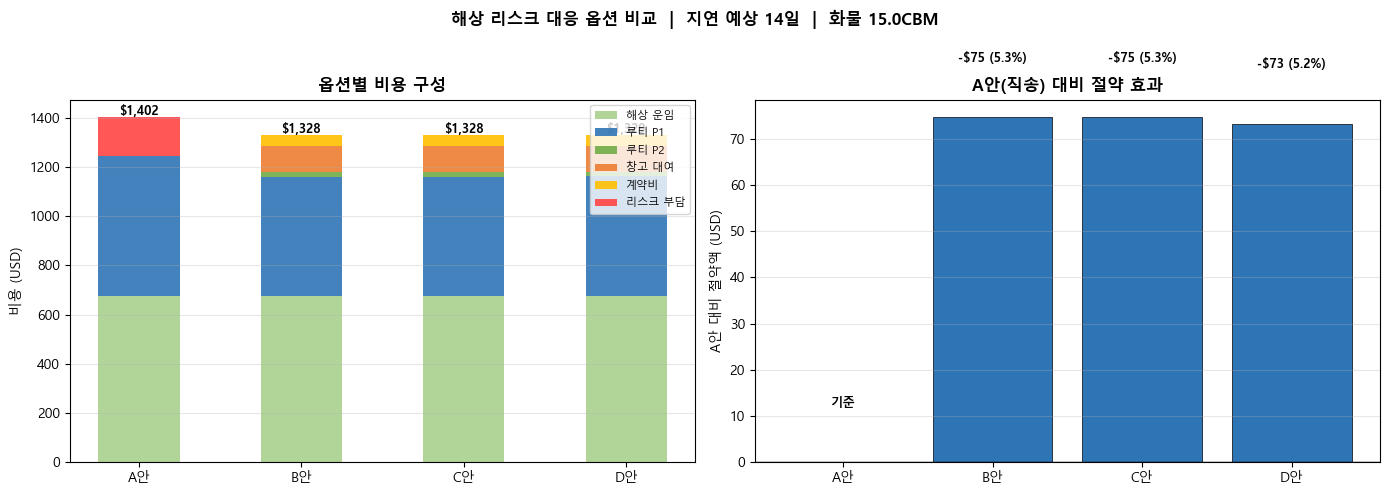

저장 완료: data/option_comparison.png

📦 선택 옵션: D안 — 거리+비용 종합 최적 (권장)
   거리·비용·시설 등급을 종합 고려한 최적 창고.  [CJ대한통운 부산 물류센터 (북항) / 1.2km]

💰 비용 상세
   루티 운송 (Phase 1): $486
   루티 운송 (Phase 2): $18
   창고 대여비:          $105
   창고 계약비:          $45
   해상 운임:            $675
   ──────────────────────────
   합계:                 $1,329
   A안 대비:             절약 $73  (5.2%)

🏭 추천 창고·ODCY
   CJ대한통운 부산 물류센터 (북항)
   주소: 부산광역시 동구 범일동
   항만까지: 1.2km / 3분
   운영: 06:00~22:00


In [17]:
# -- 4가지 대응 옵션 비교 (핵심 차별화 기능) --
# MRI 고위험 시 화주에게 A/B/C/D 4안을 제시하고 비용을 비교합니다.
# 강요 없음 -- 화주가 직접 선택. 플랫폼은 추천 + 비용 산출만 제공.
from src.option_presenter import generate_four_options, format_option_table, format_option_detail
import matplotlib.pyplot as plt
import numpy as np

# -- 시나리오 연동 (이전 셀 변수 활용) --
# MRI 조건 체크
try:
    _mri_check = today_mri
except NameError:
    _mri_check = 0.72

if _mri_check < 0.5:
    print(f'MRI {_mri_check:.3f} < 0.5 — 4가지 옵션 비교 불필요 (평상시)')
else:
    # 시나리오별 지연일수 자동 결정
    try:
        from src.scenario_engine import auto_classify_scenario
        from src.config import SCENARIOS
        _sid   = auto_classify_scenario(_mri_check, today_top_cat)
        _delay = SCENARIOS[_sid]['delay_days']
    except Exception:
        _delay = 14

    try:
        _shipment_in = SCENARIO
        _freight = int(_shipment_in.get('cbm', 15) * 45)
    except NameError:
        _shipment_in = {'cargo_type': '일반화물', 'cbm': 15.0, 'region': '경기남부'}
        _freight = 675

    try:
        _storage = result
    except NameError:
        from src.odcy_recommender import recommend_storage, CargoType
        _storage = recommend_storage('부산항(북항)', CargoType.GENERAL, top_n=3)

try:
    _storage = result
except NameError:
    from src.odcy_recommender import recommend_storage, CargoType
    _storage = recommend_storage('부산항(북항)', CargoType.GENERAL, top_n=3)

# -- 4가지 옵션 생성 --
options = generate_four_options(
    shipment       = _shipment_in,
    storage_result = _storage,
    delay_days     = _delay,
    freight_usd    = _freight,
)

print(format_option_table(options))

# -- 시각화 --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels  = [o.option_id + '안' for o in options]
stacks  = [
    ([o.freight_usd            for o in options], '해상 운임',   '#A9D18E'),
    ([o.routy_phase1_usd       for o in options], '루티 P1',     '#2E75B6'),
    ([o.routy_phase2_usd       for o in options], '루티 P2',     '#70AD47'),
    ([o.warehouse_rental_usd   for o in options], '창고 대여',   '#ED7D31'),
    ([o.warehouse_contract_usd for o in options], '계약비',      '#FFC000'),
    ([o.risk_penalty_usd       for o in options], '리스크 부담', '#FF4444'),
]
x, wid  = range(len(labels)), 0.5
bottoms = [0.0] * len(options)
for vals, lbl, col in stacks:
    ax1.bar(x, vals, wid, bottom=bottoms, label=lbl, color=col, alpha=0.9)
    bottoms = [b + v for b, v in zip(bottoms, vals)]

for i, opt in enumerate(options):
    ax1.text(i, opt.total_usd + 10, '$' + f'{opt.total_usd:,.0f}',
             ha='center', fontsize=9, fontweight='bold')
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels)
ax1.set_ylabel('비용 (USD)')
ax1.set_title('옵션별 비용 구성', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

baseline = options[0]
savings  = [opt.savings_vs(baseline) for opt in options]
bar_cols = ['#9E9E9E' if i == 0 else ('#D32F2F' if s < 0 else '#2E75B6')
            for i, s in enumerate(savings)]
ax2.bar(labels, savings, color=bar_cols, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1)

for i, (s, opt) in enumerate(zip(savings, options)):
    if i == 0:
        lbl = '기준'
    else:
        sign = '+' if s < 0 else '-'
        pct  = abs(opt.savings_pct_vs(baseline))
        lbl  = sign + '$' + f'{abs(s):,.0f} ({pct:.1f}%)'
    ypos = s + (12 if s >= 0 else -30)
    ax2.text(i, ypos, lbl, ha='center', fontsize=9, fontweight='bold')

ax2.set_ylabel('A안 대비 절약액 (USD)')
ax2.set_title('A안(직송) 대비 절약 효과', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

cbm_val = _shipment_in.get('cbm', 15)
title = (
    '해상 리스크 대응 옵션 비교'
    '  |  지연 예상 ' + str(_delay) + '일'
    '  |  화물 ' + f'{cbm_val:.1f}' + 'CBM'
)
plt.suptitle(title, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'option_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: data/option_comparison.png')

print()
opt_d = next((o for o in options if o.option_id == 'D'), options[-1])
print(format_option_detail(opt_d, baseline))


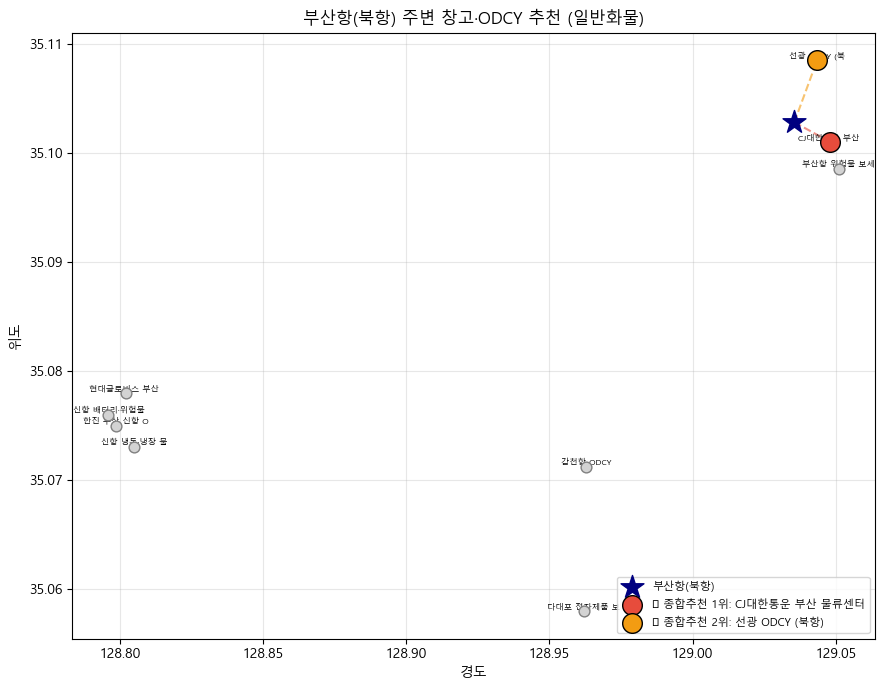


✅ 저장: data/odcy_map.png (folium 미설치 → matplotlib 대체)


In [18]:
# ── 지도 시각화 (folium 없으면 matplotlib fallback) ──────────
try:
    import folium
    from src.odcy_recommender import PORT_COORDINATES

    port_lat, port_lng = PORT_COORDINATES[SCENARIO['port_name']]
    m = folium.Map(location=[port_lat, port_lng], zoom_start=12)

    # 항만 마커
    folium.Marker(
        [port_lat, port_lng],
        popup=f"🚢 {SCENARIO['port_name']}",
        icon=folium.Icon(color='blue', icon='ship', prefix='fa'),
    ).add_to(m)

    # 추천 창고 마커
    mode_colors = {'comprehensive': 'red', 'distance': 'green', 'time': 'orange'}
    plotted_ids = set()
    for mode, color in mode_colors.items():
        for rank, wh in enumerate(result['recommendations'][mode], 1):
            wh_id = wh.get('id', wh['name'])
            if wh_id in plotted_ids:
                continue
            plotted_ids.add(wh_id)
            # 시뮬 DB는 lat/lng 있음, 카카오 결과는 추정
            sim_wh = next((w for w in __import__('src.odcy_recommender', fromlist=['SIMULATION_WAREHOUSES']).SIMULATION_WAREHOUSES
                           if w['id'] == wh_id), None)
            if sim_wh:
                folium.Marker(
                    [sim_wh['lat'], sim_wh['lng']],
                    popup=(f"<b>{wh['name']}</b><br>{wh['address']}<br>"
                           f"거리: {wh['distance_km']}km | {wh['duration_min']}분<br>"
                           f"종합추천: {'⭐' if mode=='comprehensive' and rank==1 else ''}"),
                    icon=folium.Icon(color=color, icon='warehouse', prefix='fa'),
                ).add_to(m)

    map_path = 'data/odcy_map.html'
    m.save(map_path)
    print(f"\n🗺️  지도 저장: {map_path}")
    display(m)

except ImportError:
    # folium 없을 때 matplotlib scatter
    import matplotlib.pyplot as plt
    from src.odcy_recommender import PORT_COORDINATES, SIMULATION_WAREHOUSES

    port_lat, port_lng = PORT_COORDINATES[SCENARIO['port_name']]
    fig, ax = plt.subplots(figsize=(9, 7))

    # 항만
    ax.scatter(port_lng, port_lat, s=300, c='navy', marker='*', zorder=10, label=SCENARIO['port_name'])

    # 전체 DB 창고 (회색)
    for wh in SIMULATION_WAREHOUSES:
        ax.scatter(wh['lng'], wh['lat'], s=60, c='lightgray', edgecolors='gray', zorder=5)
        ax.annotate(wh['name'][:10], (wh['lng'], wh['lat']), fontsize=6, ha='center', va='bottom')

    # 종합 추천 상위 3개 (강조)
    colors_rank = ['#e74c3c', '#f39c12', '#27ae60']
    for rank, wh_info in enumerate(result['recommendations']['comprehensive'], 1):
        sim_wh = next((w for w in SIMULATION_WAREHOUSES if w['id'] == wh_info.get('id', '')), None)
        if sim_wh:
            ax.scatter(sim_wh['lng'], sim_wh['lat'], s=200,
                       c=colors_rank[rank-1], edgecolors='black', zorder=9,
                       label=f"⭐ 종합추천 {rank}위: {sim_wh['name'][:14]}")
            ax.plot([port_lng, sim_wh['lng']], [port_lat, sim_wh['lat']],
                    '--', color=colors_rank[rank-1], alpha=0.6, linewidth=1.5)

    ax.set_xlabel('경도')
    ax.set_ylabel('위도')
    ax.set_title(f"{SCENARIO['port_name']} 주변 창고·ODCY 추천 ({SCENARIO['cargo_type'].value})", fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ROOT / 'data' / 'odcy_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ 저장: data/odcy_map.png (folium 미설치 → matplotlib 대체)")


---
# Part 6 — 루티 연계 JSON 출력 (창고 운송 Phase 1 & 2)

## 왜 2단계 JSON인가?

해상 리스크 대응은 **두 번의 운송**이 필요합니다:

```
Phase 1: 출발지 → 항만 인근 창고·ODCY   (지연 발생 즉시)
Phase 2: 창고·ODCY → 항만 CY            (선적 재개 시)
```

위밋 플랫폼이 Phase 1 JSON을 생성하면, 루티가 즉시 배차 최적화를 수행합니다.
Phase 2는 선적 재개 일정이 확정되는 시점에 자동 생성됩니다.

```
[위밋 플랫폼] → Phase 1 JSON → [루티 API] → 창고 운송 배차
                → Phase 2 JSON → [루티 API] → CY 반입 배차
```

> **현재**: `integration_status = 'simulation_mode'`
> **연동 시**: `POST /v1/dispatch/execute` 엔드포인트로 전송


In [19]:
from src.storage_routy_adapter import (
    generate_storage_routy_json, generate_phase2_routy_json, save_storage_json
)
from pathlib import Path
import json

ROUTY_DIR = ROOT / "routy_inputs"
ROUTY_DIR.mkdir(exist_ok=True)

if result is None:
    print("MRI 임계값 미만 — 루티 JSON 생성 생략 (평상시 운영)")
else:
    top_warehouse = result["recommendations"]["comprehensive"][0]

    # 화물 유형에 따른 cold_chain / hazmat 자동 결정
    _ctype   = SCENARIO.get("cargo_type_str", "일반화물")
    _cold    = _ctype in ("냉장화물", "냉동화물", "2차전지")
    _hazmat  = _ctype in ("위험물", "2차전지")
    _region  = SCENARIO.get("region", "경기남부")

    # ── Phase 1: 출발지 → 창고 ──────────────────────────────
    phase1 = generate_storage_routy_json(
        shipment_id          = SCENARIO["shipment_id"],
        company              = SCENARIO["company"],
        region               = _region,
        cargo_type           = SCENARIO["cargo_type_str"],
        cbm                  = SCENARIO["cbm"],
        cold_chain           = _cold,
        hazmat               = _hazmat,
        origin_address       = SCENARIO["origin"],
        original_port        = SCENARIO["port_name"],
        original_pickup_date = SCENARIO["pickup_date"],
        mri_current          = SCENARIO["mri_now"],
        delay_reason         = "해상 리스크 상승 (MRI 기반 HOLDBACK 결정)",
        recommended_warehouse = top_warehouse,
        phase2_ready_date    = "2026-05-25",
    )

    # ── Phase 2: 창고 → CY ──────────────────────────────────
    phase2 = generate_phase2_routy_json(
        phase1_json     = phase1,
        cy_address      = "부산광역시 동구 초량동 부산항 1부두 CY",
        cy_closing_date = "2026-05-23",
    )

    # ── 출력 & 저장 ─────────────────────────────────────────
    SEP = "=" * 60
    for phase_name, data in [("Phase 1 (출발지->창고)", phase1), ("Phase 2 (창고->CY)", phase2)]:
        print()
        print(SEP)
        print("루티 JSON --", phase_name)
        print(SEP)
        print(json.dumps(data, ensure_ascii=False, indent=2, default=str))
        fp = save_storage_json(data, ROUTY_DIR)
        print("저장 완료:", fp.name)



루티 JSON -- Phase 1 (출발지->창고)
{
  "execution_group_id": "EG-20260508-STORAGE-SH-221010",
  "generated_at": "2026-05-08T22:10:12",
  "phase": "PHASE1_TO_STORAGE",
  "phase_description": "해상 리스크 발생 → 출발지에서 항만 인근 창고·ODCY로 임시 운송",
  "risk_context": {
    "mri_current": 0.717,
    "delay_reason": "해상 리스크 상승 (MRI 기반 HOLDBACK 결정)",
    "original_port": "부산항(북항)",
    "original_pickup": "2026-05-20",
    "decision": "HOLDBACK_TO_STORAGE"
  },
  "shipment": {
    "shipment_id": "SH-221010",
    "company": "테스트화주(주)",
    "region": "경기남부",
    "cargo_type": "일반화물",
    "cbm": 15.0,
    "cold_chain": false,
    "hazmat": false,
    "origin_address": "경기도 수원시 영통구"
  },
  "dispatch": {
    "origin": {
      "name": "테스트화주(주) 출고지",
      "address": "경기도 수원시 영통구"
    },
    "destination": {
      "name": "CJ대한통운 부산 물류센터 (북항)",
      "address": "부산광역시 동구 범일동",
      "phone": "051-XXX-XXXX",
      "type": "물류창고",
      "lat": null,
      "lng": null
    },
    "adjusted_pickup": "2026-05-19",
    "acti